In [1]:
import pandas as pd
import seaborn as sns

In [2]:
dt = pd.read_csv('top-5000-youtube-channels.csv')

In [4]:
dt.head(-5)

,Rank,Grade,Channel name,Video Uploads,Subscribers,Video views
0,1st,A++,Zee TV,82757,18752951,20869786591
1,2nd,A++,T-Series,12661,61196302,47548839843
2,3rd,A++,Cocomelon - Nursery Rhymes,373,19238251,9793305082
3,4th,A++,SET India,27323,31180559,22675948293
4,5th,A++,WWE,36756,32852346,26273668433
...,...,...,...,...,...,...
4990,"4,991st",B+,Ho Ngoc Ha's Official Channel,208,--,127185704
4991,"4,992nd",B+,Toys to Learn Colors,11,663114,141933264
4992,"4,993rd",B+,КАZКА,25,131766,74304638
4993,"4,994th",B+,United CUBE (CUBE Entertainment…,1055,1586835,371299166


In [7]:
dt.tail(-5)

,Rank,Grade,Channel name,Video Uploads,Subscribers,Video views
5,6th,A++,Movieclips,30243,17149705,16618094724
6,7th,A++,netd müzik,8500,11373567,23898730764
7,8th,A++,ABS-CBN Entertainment,100147,12149206,17202609850
8,9th,A++,Ryan ToysReview,1140,16082927,24518098041
9,10th,A++,Zee Marathi,74607,2841811,2591830307
...,...,...,...,...,...,...
4995,"4,996th",B+,Uras Benlioğlu,706,2072942,441202795
4996,"4,997th",B+,HI-TECH MUSIC LTD,797,1055091,377331722
4997,"4,998th",B+,Mastersaint,110,3265735,311758426
4998,"4,999th",B+,Bruce McIntosh,3475,32990,14563764


In [8]:
dt.shape
print('Number of Rows', dt.shape[0])
print('Number of Column', dt.shape[1])

Number of Rows 5000
Number of Column 6


In [9]:
dt.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Rank           5000 non-null   str  
 1   Grade          5000 non-null   str  
 2   Channel name   5000 non-null   str  
 3   Video Uploads  5000 non-null   str  
 4   Subscribers    5000 non-null   str  
 5   Video views    5000 non-null   int64
dtypes: int64(1), str(5)
memory usage: 234.5 KB


In [17]:
pd.options.display.float_format = '{:.2f}'.format

In [18]:
dt.describe()

,Video views
count,5000.00
mean,1071449400.15
std,2003843972.12
min,75.00
25%,186232945.75
50%,482054780.00
75%,1124367826.75
max,47548839843.00


In [19]:
import numpy as np

In [22]:
dt=dt.replace('--', np.nan, regex=True)

In [23]:
dt.head(20)

,Rank,Grade,Channel name,Video Uploads,Subscribers,Video views
0,1st,A++,Zee TV,82757,18752951,20869786591
1,2nd,A++,T-Series,12661,61196302,47548839843
2,3rd,A++,Cocomelon - Nursery Rhymes,373,19238251,9793305082
3,4th,A++,SET India,27323,31180559,22675948293
4,5th,A++,WWE,36756,32852346,26273668433
5,6th,A++,Movieclips,30243,17149705,16618094724
6,7th,A++,netd müzik,8500,11373567,23898730764
7,8th,A++,ABS-CBN Entertainment,100147,12149206,17202609850
8,9th,A++,Ryan ToysReview,1140,16082927,24518098041
9,10th,A++,Zee Marathi,74607,2841811,2591830307


In [24]:
dt.isnull().sum()

Rank               0
Grade              0
Channel name       0
Video Uploads      6
Subscribers      387
Video views        0
dtype: int64

In [27]:
per_missing = dt.isnull().sum() * 100/ len(dt)
per_missing

Rank            0.00
Grade           0.00
Channel name    0.00
Video Uploads   0.12
Subscribers     7.74
Video views     0.00
dtype: float64

<Axes: >

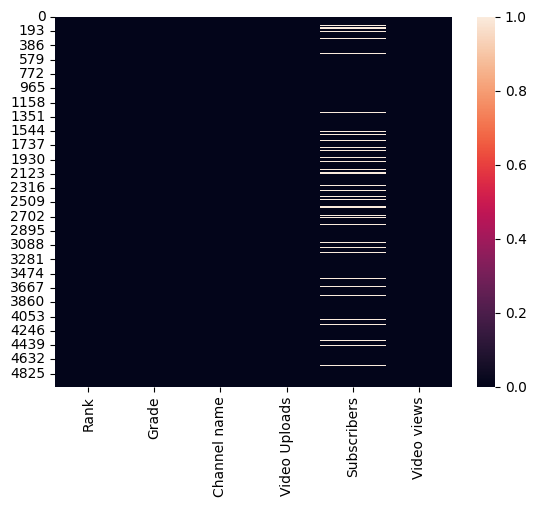

In [29]:
sns.heatmap(dt.isnull())

In [30]:
dt.dropna(axis=0, inplace=True)

<Axes: >

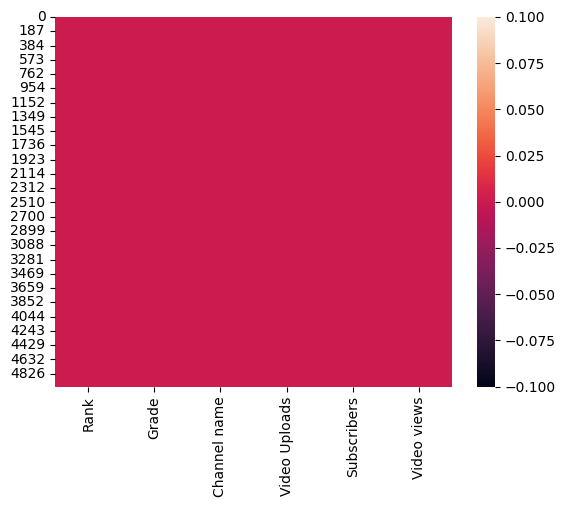

In [31]:
sns.heatmap(dt.isnull())

In [32]:
dt.dtypes

Rank               str
Grade              str
Channel name       str
Video Uploads      str
Subscribers        str
Video views      int64
dtype: object

In [34]:
dt['Rank']=dt['Rank'].str[0:-2]

In [36]:
dt['Rank']=dt['Rank'].str.replace(',','').astype('int')

In [42]:
dt.dtypes

Rank             int64
Grade              str
Channel name       str
Video Uploads    int64
Subscribers      int64
Video views      int64
dtype: object

In [39]:
dt['Video Uploads']=dt['Video Uploads'].astype('int')

In [40]:
dt['Subscribers']=dt['Subscribers'].astype('int')

In [41]:
dt.dtypes

Rank             int64
Grade              str
Channel name       str
Video Uploads    int64
Subscribers      int64
Video views      int64
dtype: object

In [43]:
dt['Grade'].unique()

<StringArray>
['A++ ', 'A+ ', 'A ', 'A- ', 'B+ ']
Length: 5, dtype: str

In [45]:
dt['Grade']=dt['Grade'].map({'A++ ':5, 'A+ ':4, 'A ':3, 'A- ':2, 'B+ ':1})

In [46]:
dt.dtypes

Rank             int64
Grade            int64
Channel name       str
Video Uploads    int64
Subscribers      int64
Video views      int64
dtype: object

In [47]:
dt.columns

Index(['Rank', 'Grade', 'Channel name', 'Video Uploads', 'Subscribers',
       'Video views'],
      dtype='str')

In [48]:
dt['Avg_views']=dt['Video views']/dt['Video Uploads']

In [50]:
dt.head(3)

,Rank,Grade,Channel name,Video Uploads,Subscribers,Video views,Avg_views
0,1,5,Zee TV,82757,18752951,20869786591,252181.53
1,2,5,T-Series,12661,61196302,47548839843,3755535.89
2,3,5,Cocomelon - Nursery Rhymes,373,19238251,9793305082,26255509.60


In [51]:
dt.sort_values(by ='Video Uploads', ascending=False).head()

,Rank,Grade,Channel name,Video Uploads,Subscribers,Video views,Avg_views
3453,3454,1,AP Archive,422326,746325,548619569,1299.04
1149,1150,2,YTN NEWS,355996,820108,1640347646,4607.77
2223,2224,1,SBS Drama,335521,1418619,1565758044,4666.65
323,324,3,GMA News,269065,2599175,2786949164,10357.90
2956,2957,1,MLB,267649,1434206,1329206392,4966.23


In [53]:
dt.corr(numeric_only=True)

,Rank,Grade,Video Uploads,Subscribers,Video views,Avg_views
Rank,1.00,-0.87,-0.07,-0.38,-0.40,-0.15
Grade,-0.87,1.00,0.09,0.43,0.48,0.16
Video Uploads,-0.07,0.09,1.00,0.01,0.09,-0.06
Subscribers,-0.38,0.43,0.01,1.00,0.79,0.29
Video views,-0.40,0.48,0.09,0.79,1.00,0.29
Avg_views,-0.15,0.16,-0.06,0.29,0.29,1.00


In [54]:
dt.columns

Index(['Rank', 'Grade', 'Channel name', 'Video Uploads', 'Subscribers',
       'Video views', 'Avg_views'],
      dtype='str')

<Axes: xlabel='Grade', ylabel='Video Uploads'>

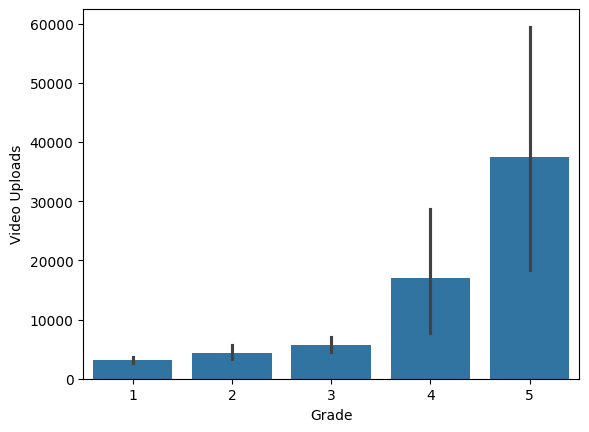

In [56]:
sns.barplot(x='Grade',y='Video Uploads', data=dt)

In [57]:
dt.columns

Index(['Rank', 'Grade', 'Channel name', 'Video Uploads', 'Subscribers',
       'Video views', 'Avg_views'],
      dtype='str')

<Axes: xlabel='Grade', ylabel='Avg_views'>

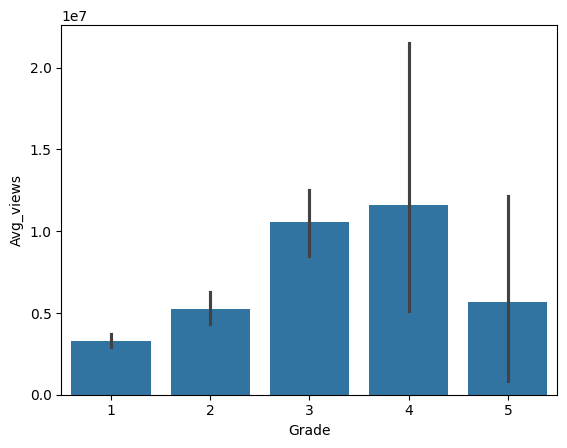

In [58]:
sns.barplot(x='Grade',y='Avg_views', data=dt)

In [59]:
dt.columns

Index(['Rank', 'Grade', 'Channel name', 'Video Uploads', 'Subscribers',
       'Video views', 'Avg_views'],
      dtype='str')

<Axes: xlabel='Grade', ylabel='Subscribers'>

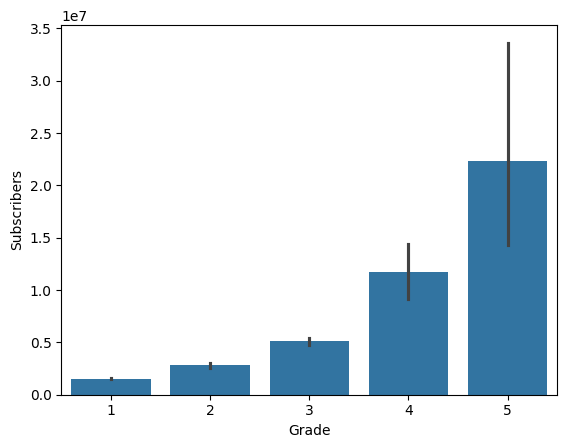

In [60]:
sns.barplot(x='Grade',y='Subscribers', data=dt)

In [62]:
dt.groupby('Grade').mean(numeric_only=True)

,Rank,Video Uploads,Subscribers,Video views,Avg_views
Grade,,,,,
1,3520.54,3136.16,1535207.95,555183839.09,3280380.88
2,1533.99,4382.58,2798520.38,1102450027.69,5254804.04
3,534.29,5709.86,5107136.29,2497972949.11,10540908.45
4,31.32,16960.30,11726947.47,6168741772.73,11577080.32
5,5.50,37450.70,22281762.50,21199091192.80,5688267.96
